# L05：沿哪个轴卷积？

用小张量计算局部乘加，再观察真实模型接口。训练过程在10_training_step_classroom中演示。

In [1]:
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/hsi_learning').is_dir() and (p / 'dataset').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the HSI-Learning repository')
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np
import torch
# Notebook kernels must explicitly use inline rendering even when the CLI
# parent uses MPLBACKEND=Agg for non-interactive training scripts.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
import matplotlib.pyplot as plt
from hsi_learning.data import load_hsi_dataset
from hsi_learning.teaching_runs import load_bundle, encode_ids
from hsi_learning.teaching import patches_at, prototype_logits, prototypes, grad_cam
from hsi_learning.teaching_plots import style, maps
style()
torch.set_num_threads(2)
print('Python:', sys.executable)
print('Repository:', ROOT)


Python: D:\JupyterWorkSpace\HSI-Learning\.venv\Scripts\python.exe
Repository: D:\JupyterWorkSpace\HSI-Learning


In [2]:
import torch.nn as nn
x=torch.arange(1,6,dtype=torch.float32).reshape(1,1,5)
conv=nn.Conv1d(1,1,3,bias=False)
with torch.no_grad(): conv.weight.copy_(torch.tensor([[[1.,0.,-1.]]]))
print('Hand result [-2,-2,-2]:',conv(x))
torch.testing.assert_close(conv(x),torch.tensor([[[-2.,-2.,-2.]]]))


Hand result [-2,-2,-2]: tensor([[[-2., -2., -2.]]], grad_fn=<ConvolutionBackward0>)


In [3]:
one=nn.Conv1d(1,32,7); two=nn.Conv2d(12,32,3); three=nn.Conv3d(1,8,(7,3,3))
print('1D:',one(torch.zeros(2,1,200)).shape)
print('2D:',two(torch.zeros(2,12,9,9)).shape)
print('3D:',three(torch.zeros(2,1,15,9,9)).shape)
assert sum(p.numel() for p in two.parameters())==3488
print('2D kernel sees all input channels:',two.weight.shape)


1D: torch.Size([2, 32, 194])
2D: torch.Size([2, 32, 7, 7])
3D: torch.Size([2, 8, 9, 7, 7])
2D kernel sees all input channels: torch.Size([32, 12, 3, 3])


In [4]:
r,jump=1,1
for kernel,stride in [(7,1),(2,2),(5,1),(2,2),(3,1)]:
    r+=(kernel-1)*jump; jump*=stride; print('RF / jump:',r,jump)
assert r==26
print('RF includes padding locations; it is not a wavelength range.')


RF / jump: 7 1
RF / jump: 8 2
RF / jump: 16 2
RF / jump: 18 4
RF / jump: 26 4
RF includes padding locations; it is not a wavelength range.


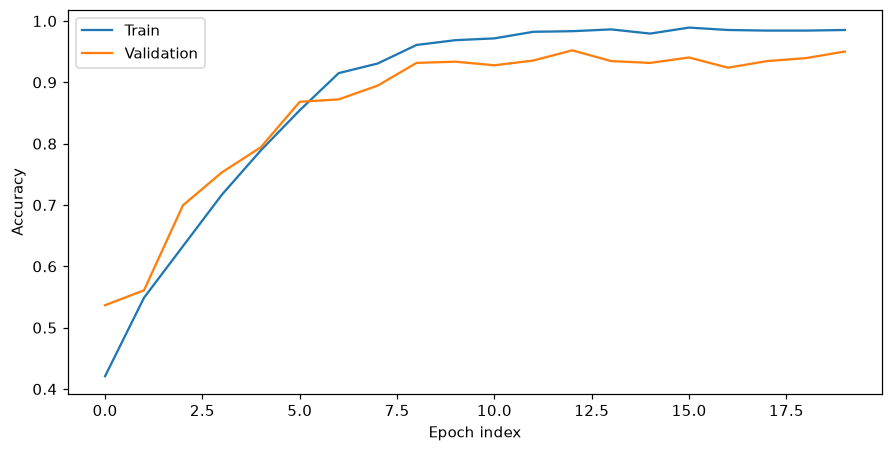

Protocol E, train-fitted PCA12, patch9, seed42, budget: 20


In [5]:
import json
base=ROOT/'results/teaching_ready/classifier-ce'
history=json.loads((base/'history.json').read_text()); cfg=json.loads((base/'run_config.json').read_text())
fig,ax=plt.subplots(figsize=(8,4),layout='constrained')
ax.plot(history['train_accuracy'],label='Train'); ax.plot(history['val_accuracy'],label='Validation')
ax.set_xlabel('Epoch index'); ax.set_ylabel('Accuracy'); ax.legend(); plt.show()
print('Protocol E, train-fitted PCA12, patch9, seed42, budget:',cfg['epochs'])


## 退出题
改变batch会不会改变参数量？
Conv2d的通道聚合和Conv3d的depth滑动有何区别？
为什么不能用不同patch、PCA和训练预算的分数证明卷积维数优劣？